# Imaging Performance Comparison (Quiet Sun)
This notebook loops over different noise levels and calibration errors to generate, corrupt, image, and compare solar flare datasets.

In [3]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from scipy.special import j1
from scipy.constants import c
import os
import glob
from casatasks import tclean, applycal, clearcal
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from astropy.time import Time
from sunpy import coordinates

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

In [4]:
from importlib import reload

reload(fss)
target = 'Quiet_Sun'
figsubfolder = 'figs/'
model_dir = '../fasr_sim/skymodels/quiet_sun/'

# Imaging Performance Comparison
looping over different noise levels and calibration errors to generate, corrupt, image, and compare

## Set up the simulation

In [5]:
# List of all available frequencies in GHz
freq_list = ['1GHz', '2GHz', '5GHz', '10GHz', '20GHz']
imsizes = [512, 512, 1024, 2048, 4096]
cells = ['4.8arcsec', '4.8arcsec', '2.4arcsec', '1.2arcsec', '0.6arcsec']
scales = [[0, 5, 10, 50], [0, 4, 10, 40], [0, 6, 20, 80], [0, 5, 10, 40, 160], [0, 10, 40, 80, 320]]

selection = [0, 1]
# Revise freq_list, imsizes, cells, and scales using the selection
freq_list = [freq_list[i] for i in selection]
imsizes = [imsizes[i] for i in selection]
cells = [cells[i] for i in selection]
scales = [scales[i] for i in selection]


# List of configurations
project = 'FASR-A'
#config_files = ['fasr_Log_Spiral-168.cfg', 'fasr-a_random_spiral_hybrid_120.cfg']
config_files = ['fasr-a_random_spiral_hybrid_120.cfg']

## Antenna temperature noise levels
tsys_all = [300.]

## Define the fractional gain errors tuples: (phase and amplitude)
# 6 degrees (or 1.7% of phase error is equivalent to 10% of amplitude error )
#cal_errors = [(0., 0.), (0.017, 0.1)]
cal_errors = [(0., 0.)]

# Define channel width and integration time
channel_width_mhz = 24. # channel width in MHz
integration_time = 1. # Time per integration in seconds
duration = 1. # Total imaging duration in seconds

# Reference timestamp for the observation series
reftime='2020-11-26T20:45:47'
solar_radius_asec = coordinates.sun.angular_radius(reftime).value

# Flags to control overwriting existing data products
overwrite_ms   = False  # Overwrite measurement set?
overwrite_im   = False  # Overwrite image products?
overwrite_plot = True  # Overwrite existing plots?

weighting = 'uniform'
# Deconvolution algorithm choice
#deconvolver = 'hogbom'
#niter = 0

deconvolver = 'multiscale'
niter = 10000
 

## Mask Models based on background levels

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0001 Jy/pixel at 1.00 GHz
Background level at 1.00 GHz: 0.0004 Jy/pixel


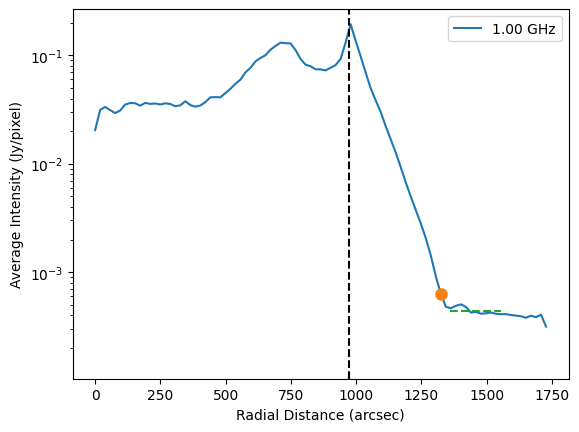

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.1GHz.masked.fits (RADCUT=1324.80 arcsec)


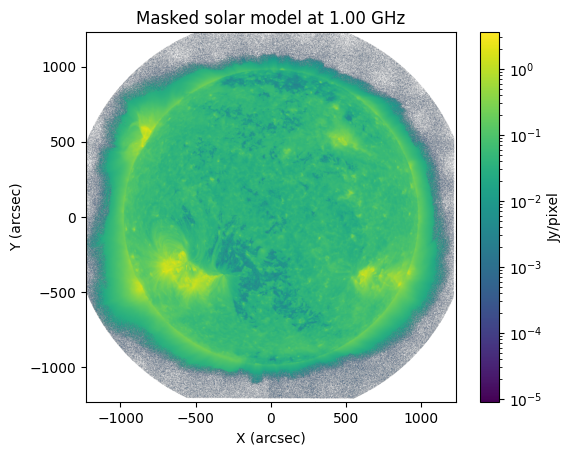

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0001 Jy/pixel at 1.00 GHz
Background level at 1.00 GHz: 0.0018 Jy/pixel


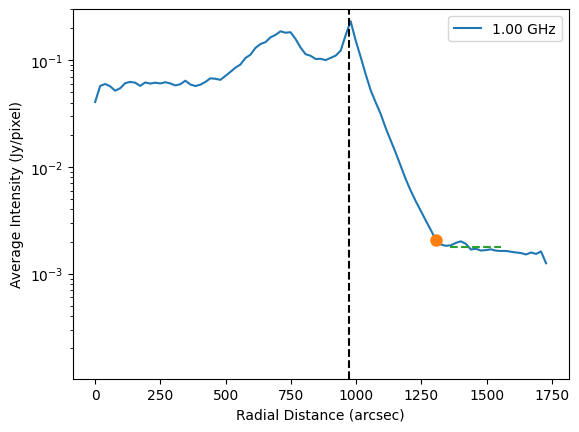

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.2GHz.masked.fits (RADCUT=1305.60 arcsec)


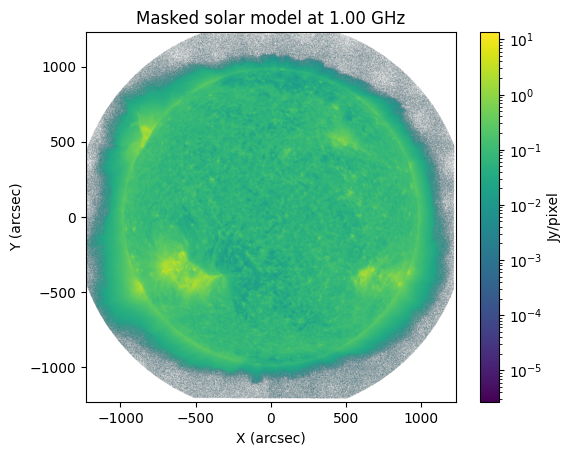

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0001 Jy/pixel at 1.00 GHz
Background level at 1.00 GHz: 0.0070 Jy/pixel


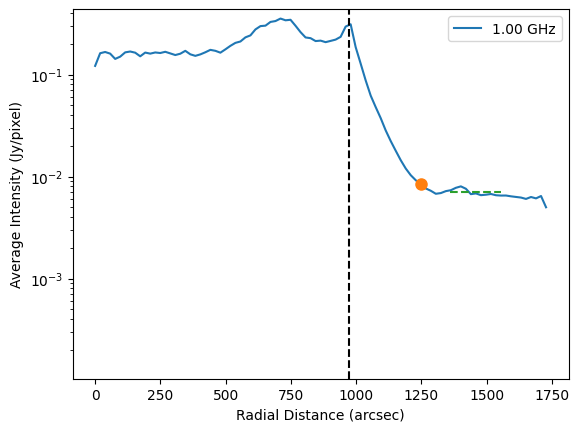

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.4GHz.masked.fits (RADCUT=1248.00 arcsec)


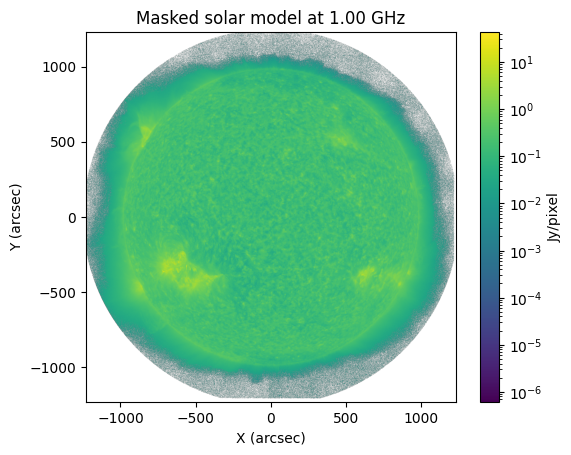

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0026 Jy/pixel at 5.02 GHz
Background level at 5.02 GHz: 0.0111 Jy/pixel


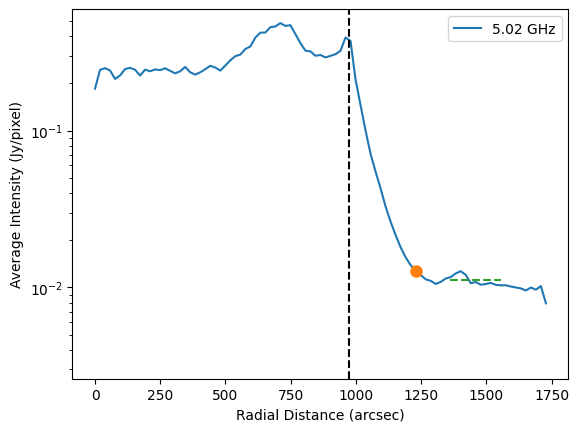

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.5GHz.masked.fits (RADCUT=1228.80 arcsec)


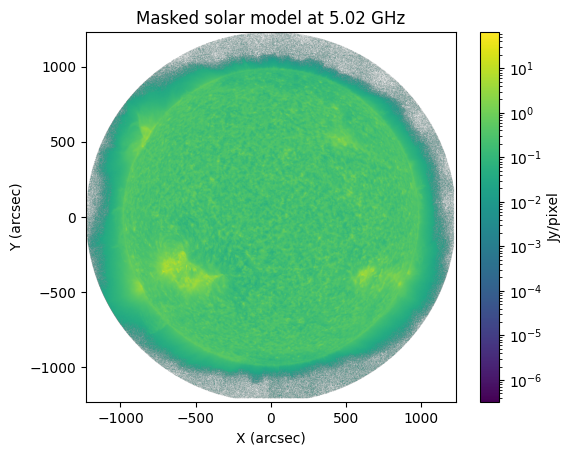

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0066 Jy/pixel at 7.96 GHz
Background level at 7.96 GHz: 0.0280 Jy/pixel


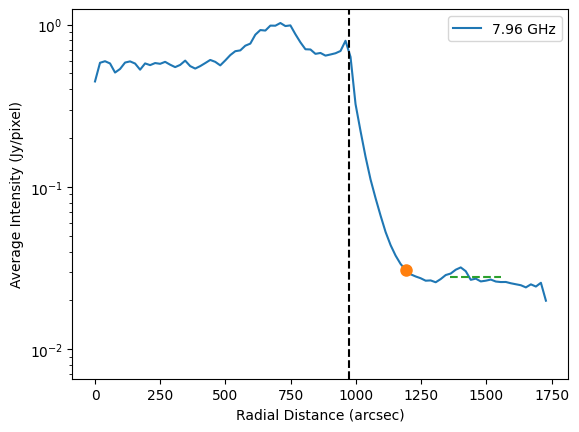

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.8GHz.masked.fits (RADCUT=1190.40 arcsec)


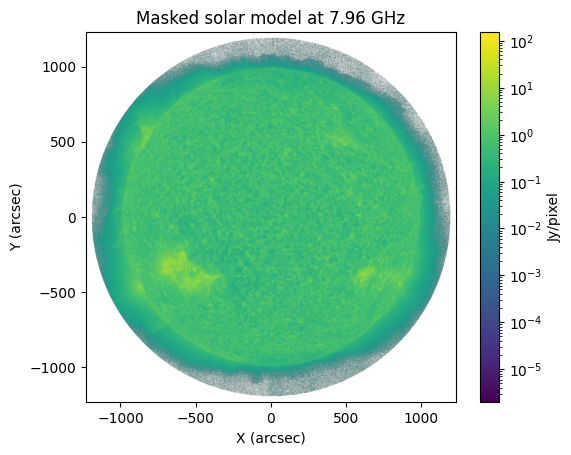

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0001 Jy/pixel at 1.00 GHz
Background level at 1.00 GHz: 0.0444 Jy/pixel


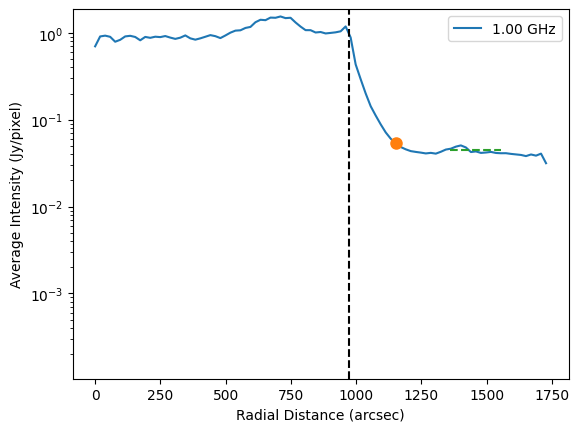

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.10GHz.masked.fits (RADCUT=1152.00 arcsec)


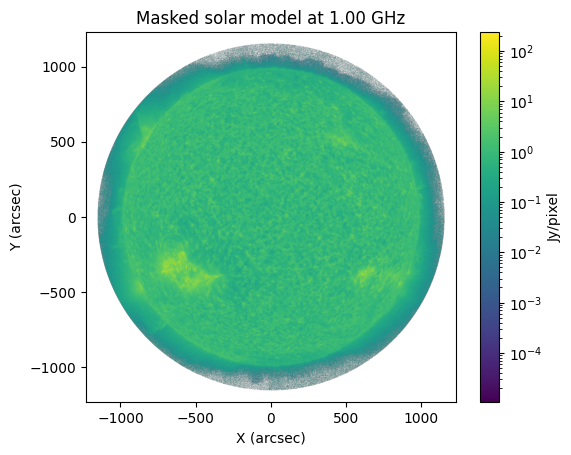

Pixel scale: 1.20 x 1.20 arcsec
Minimum flux threshold: 0.0001 Jy/pixel at 1.00 GHz
Background level at 1.00 GHz: 0.1769 Jy/pixel


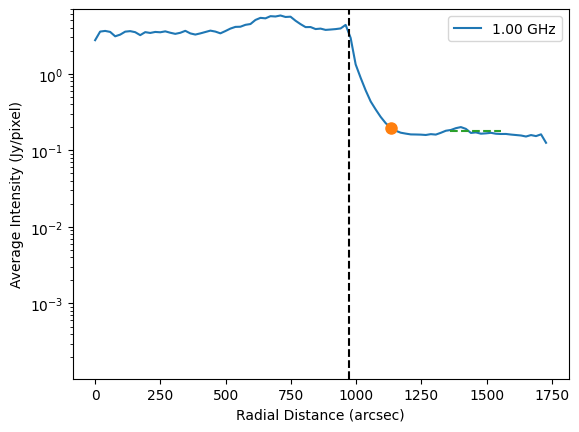

Masked solar model written to ../fasr_sim/skymodels/quiet_sun//solar_disk_model_20201126.20GHz.masked.fits (RADCUT=1132.80 arcsec)


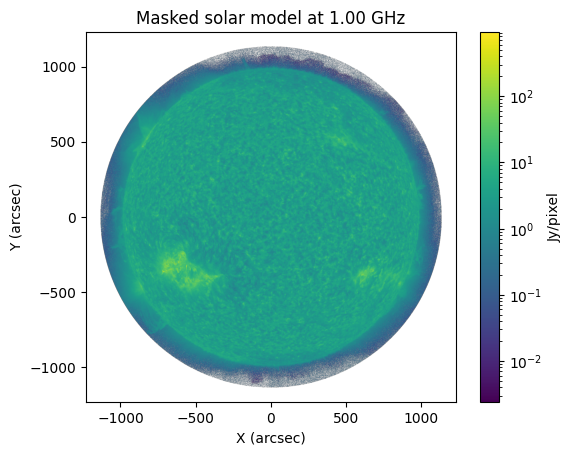

In [6]:
reload(fss)
freq_list=['1GHz', '2GHz', '4GHz', '5GHz', '8GHz','10GHz', '20GHz']
radius_cutoffs = []
for freqstr in freq_list:
    solar_model = f'{model_dir}/solar_disk_model_20201126.{freqstr}.fits'
    radius_list, mean_intensity_profile, background_level, radius_cutoff = fss.calc_model_radial_profile(solar_model, dr=20, tb_min=100., bkg_radius_range=[1.4, 1.6], snr_min=1.1, apply_mask=True)
    radius_cutoffs.append(radius_cutoff)

## Imaging Test: Hybrid 120 vs +10 Remote Antennas (3–6 km)
This section runs a small imaging test and compares:
- Base: `fasr-a_random_spiral_hybrid_120.cfg`
- Remote: `fasr-a_random_spiral_hybrid_120_remote10_r3-6km.cfg`

It uses the same sky model and imaging parameters for both, so differences are driven by UV-coverage / weighting.

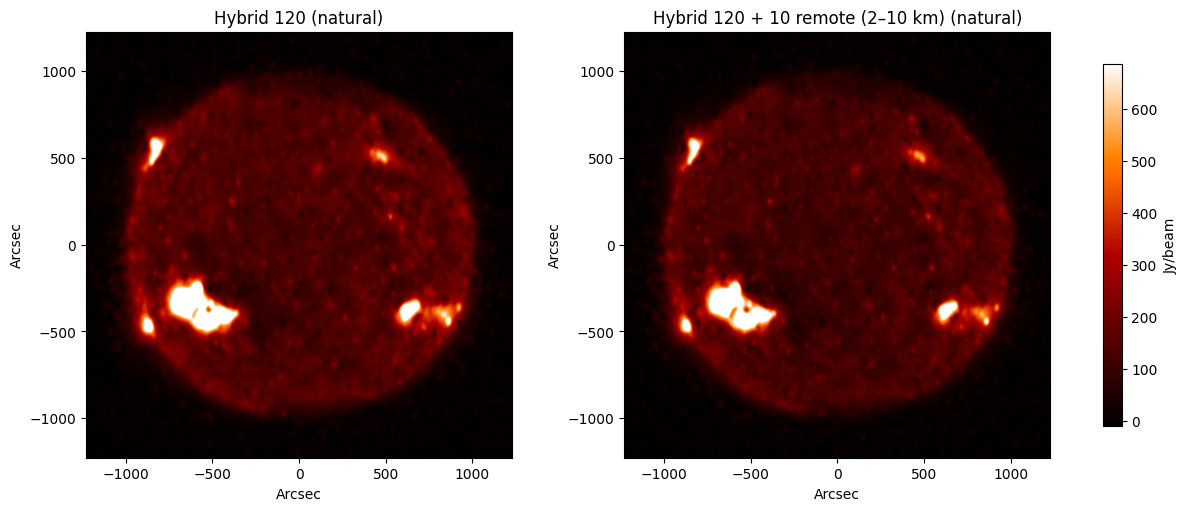

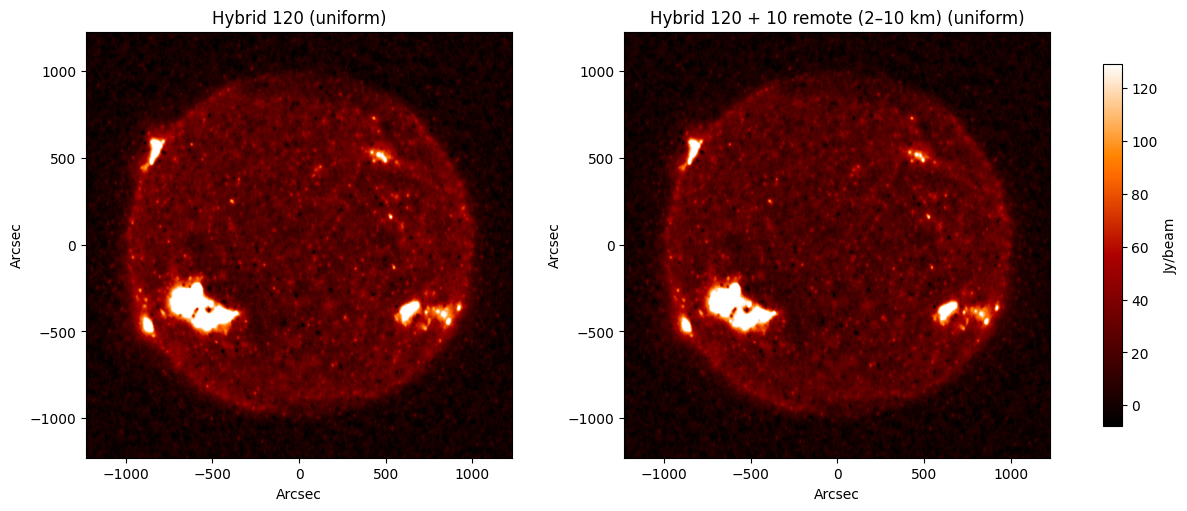

In [7]:
# --- Configs to compare ---
base_cfg = 'fasr-a_random_spiral_hybrid_120.cfg'
remote_cfg = 'fasr-a_random_spiral_hybrid_120_remote10_r3-6km.cfg'
remote_cfg = 'fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg'

# --- Quick test parameters (edit as needed) ---
freqstr = '5GHz'
solar_model = f'{model_dir}/solar_disk_model_20201126.{freqstr}.masked.fits'

# imaging grid (try smaller cell for super-resolution experiments)
imsize = 1024
cell = '2.4arcsec'
scales = [0, 6, 20, 80]

# noise / integration
tsys = 300.
channel_width_mhz = 24.
integration_time = 1.
duration = 1.

# calibration errors (set to 0 for this test)
phaerr = 0.
amperr = 0.

# baseline CASA timestamp
reftime_casa = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')

# Make sure output dirs exist
figdir = os.path.join(project, figsubfolder)
os.makedirs(figdir, exist_ok=True)
caltbdir = os.path.join(project, 'caltbs')
os.makedirs(caltbdir, exist_ok=True)

configs = [base_cfg, remote_cfg]
remote_cfg_base = os.path.basename(remote_cfg).replace('.cfg', '')
remote_parts = remote_cfg_base.split('_')
remote_count = next((p.replace('remote', '') for p in remote_parts if p.startswith('remote')), '?')
remote_range = next((p[1:] for p in remote_parts if p.startswith('r') and p.endswith('km') and '-' in p), '?-?km')
remote_range_label = remote_range.replace('km', ' km').replace('-', '–')
remote_label = f'Hybrid 120 + {remote_count} remote ({remote_range_label})'
labels = ['Hybrid 120', remote_label]
weightings = ['natural', 'uniform']

for weighting in weightings:
    ims = []
    for config_file in configs:
        msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, config_file, tsys)
        msfile = f'{msname}.ms'

        if (not os.path.exists(msfile)) or overwrite_ms:
            if os.path.exists(msfile) and overwrite_ms:
                os.system('rm -rf ' + msfile)
            print('Start generating ms:', msfile)
            msfile = fss.generate_ms(
                config_file, solar_model, reftime_casa, freqstr,
                integration_time=integration_time, duration=duration,
                channel_width_mhz=channel_width_mhz,
                msname=msfile, tsys=tsys, usehourangle=True
            )

        # Make an image name that includes cfg + weighting
        imname = f'{msname}_{weighting}_multiscale'
        if os.path.exists(f'{imname}.image') and overwrite_im:
            for j in ['.image', '.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                os.system(f'rm -rf {imname}{j}')

        if not os.path.exists(f'{imname}.image'):
            print('Imaging:', imname)
            tclean(
                vis=msfile, imagename=imname,
                datacolumn='data',
                specmode='mfs',
                deconvolver='multiscale', scales=scales,
                gain=0.2, cycleniter=200, minpsffraction=0.1, pblimit=0.01,
                imsize=imsize, cell=cell,
                weighting=weighting,
                niter=10000,
                interactive=False
            )
            for j in ['.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']:
                os.system(f'rm -rf {imname}{j}')

        ims.append(imname + '.image')

    # Compare the two configs side-by-side (both convolved to a common resolution)
    figname = os.path.join(figdir, f'fig-compare_remote10_r3-6km_{freqstr}_{weighting}.jpg')
    if os.path.exists(figname) and overwrite_plot:
        os.system('rm -rf ' + figname)

    if not os.path.exists(figname):
        # Simple side-by-side plot of the two CASA images (no inset / no contour overlay)
        from casatools import image as IA
        import numpy as _np
        
        def _read_casa_image(imdir):
            ia = IA()
            ia.open(imdir)
            pix = ia.getchunk()[:, :, 0, 0]
            csys = ia.coordsys()
            inc = _np.array(csys.increment()['numeric'][0:2]) * (180.0 / _np.pi) * 3600.0  # arcsec/pix
            unit = ia.summary().get('unit', '')
            ia.close()
            nx, ny = pix.shape
            extent = (-nx/2*abs(inc[0]), nx/2*abs(inc[0]), -ny/2*abs(inc[1]), ny/2*abs(inc[1]))
            return pix, extent, unit
        
        pix1, ext1, unit1 = _read_casa_image(ims[0])
        pix2, ext2, unit2 = _read_casa_image(ims[1])
        
        # shared color scale across both images
        stack = _np.hstack([pix1.ravel(), pix2.ravel()])
        vmin, vmax = _np.nanpercentile(stack, [1, 99])
        
        fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
        im = axs[0].imshow(pix1.T, origin='lower', extent=ext1, cmap='hinodexrt', vmin=vmin, vmax=vmax)
        axs[0].set_title(f'{labels[0]} ({weighting})')
        axs[0].set_xlabel('Arcsec')
        axs[0].set_ylabel('Arcsec')
        
        axs[1].imshow(pix2.T, origin='lower', extent=ext2, cmap='hinodexrt', vmin=vmin, vmax=vmax)
        axs[1].set_title(f'{labels[1]} ({weighting})')
        axs[1].set_xlabel('Arcsec')
        axs[1].set_ylabel('Arcsec')
        
        cbar = fig.colorbar(im, ax=axs, shrink=0.85)
        cbar.set_label(unit1 or unit2)


## Super-Resolution / Long-Baseline Emphasis Options
With only a small number of remote antennas, the very long baselines are sparse. Even `uniform` weighting may not emphasize them enough. Below are two practical approaches that can push resolution beyond what uniform weighting gives.

1) **UV-range split + combine**: image long baselines only (high-res) and short baselines only (low-res), then combine in the image domain (e.g., `feather`).
2) **Manual weight boost**: multiply the MS `WEIGHT` / `SIGMA` by a function of UV-distance to upweight long baselines more strongly than uniform weighting.

Notes:
- Both methods increase noise in the final image and can create ringing if the long-baseline PSF sidelobes are high.
- Multi-scale deconvolution and tighter clean masks help stability.

In [25]:
from math import sqrt

# Helper: parse CASA freq strings like '5GHz' or '1.00GHz' -> Hz
def _freqstr_to_hz(freqstr):
    s = freqstr.strip()
    if s.lower().endswith('ghz'):
        return float(s[:-3]) * 1e9
    if s.lower().endswith('mhz'):
        return float(s[:-3]) * 1e6
    if s.lower().endswith('khz'):
        return float(s[:-3]) * 1e3
    if s.lower().endswith('hz'):
        return float(s[:-2])
    raise ValueError(f'Unrecognized freq string: {freqstr}')

imsize = 1024
cell = '2.4arcsec'
scales = [0, 6, 20, 80]
duration = 1.
integration_time = 1.
channel_width_mhz = 24.
tsys = 300.

# Tip: CASA also supports weighting='superuniform' (often more aggressive than 'uniform' for sparse long baselines).

# --- (A) UV-range split + feather combine ---
# Choose a threshold at which you consider baselines "long".
# Rough guide at 5 GHz (lambda ~ 6 cm):
#   3 km ~ 50 klambda, 6 km ~ 100 klambda
uvthr_klambda = 2.0
# uvthr_klambda = 3.0

# Example: make two images from the REMOTE config ms (short-only and long-only)
# (Make sure msfile_remote points to the correct MS; re-run the cell above first.)
msname_remote = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, remote_cfg, tsys)
msfile_remote = f'{msname_remote}.ms'


# Example usage on the REMOTE MS
uv0_klambda = 20  # scale at which boost starts to matter (try 10 klambda for 5 GHz)
power = 2.0
max_boost = 10.0
msfile_boost = msfile_remote.replace('.ms', f'_wboost_uv0{uv0_klambda}k_p{power}.ms')

short_im = f'{msname_remote}_uvlt{uvthr_klambda}k_{cell}_natural'
long_im  = f'{msname_remote}_uvgt{uvthr_klambda}k_{cell}_uniform'
feather_im = f'{msname_remote}_feather_uvthr{uvthr_klambda}k'
boost_im = msfile_boost.replace('.ms', '') + '_image'

# os.system('rm -rf ' + short_im + '.image')  # remove any existing short-baseline image to avoid confusion
# os.system('rm -rf ' + long_im + '.image')  # remove any existing long-baseline image to avoid confusion
# os.system('rm -rf ' + feather_im + '.image')  # remove any existing feather image to avoid confusion
# os.system('rm -rf ' + boost_im + '.image')  # remove any existing boosted image to avoid confusion


if not os.path.exists(short_im + '.image'):
    tclean(
        vis=msfile_remote, imagename=short_im,
        datacolumn='data', specmode='mfs',
        deconvolver='multiscale', scales=scales,
        imsize=imsize, cell=cell,
        weighting='uniform',
        uvrange=f'<{uvthr_klambda}klambda',
        niter=10000, interactive=False
    )
else:
    print('Short-baseline image already exists, skipping:', short_im + '.image')


if not os.path.exists(long_im + '.image'):
    # For the long-baseline image, try a smaller cell to avoid undersampling.
    tclean(
        vis=msfile_remote, imagename=long_im,
        datacolumn='data', specmode='mfs',
        deconvolver='multiscale', scales=[0,3,10,30],
        imsize=imsize, cell=cell,
        weighting='uniform',  # try to get a more uniform weighting for the long baselines
        uvrange=f'>{uvthr_klambda}klambda',
        niter=10000, interactive=False
    )
else:
    print('Long-baseline image already exists, skipping:', long_im + '.image')

# Feather combine (requires casatasks.feather).
# Feather expects low-res first, high-res second. Both images must be on same grid.
try:
    from casatasks import feather
    if not os.path.exists(feather_im + '.image'):
        feather(imagename=feather_im, lowres=short_im + '.image', highres=long_im + '.image', sdfactor=2.0)
        print('Wrote:', feather_im + '.image')
    else:
        print('Feather image already exists, skipping:', feather_im + '.image')
except Exception as e:
    print('feather not available in this CASA environment:', e)


# --- (B) Manual long-baseline weight boost (more aggressive than uniform) ---
# This creates a COPY of the MS and scales WEIGHT/SIGMA as a function of UV distance.
# Use with care: it will increase noise and can make deconvolution harder.

# Parameters:
#   uv0_klambda: scale where boost starts to matter
#   power: how steeply weights increase with baseline length
#   max_boost: cap to avoid extreme amplification
#   uvrange_min_klambda: only boost beyond this

def boost_long_baseline_weights(ms_in, ms_out, freqstr, uv0_klambda=30, power=2.0, max_boost=50.0, uvrange_min_klambda=0.0):
    """Create a copy of an MS and reweight rows by UV distance.

    This function scales per-row CASA visibility weights to emphasize longer
    baselines (higher spatial frequencies):
      - WEIGHT is multiplied by ``boost``
      - SIGMA is divided by ``sqrt(boost)``
      - WEIGHT_SPECTRUM (if present) is scaled consistently

    The boost model is:
        boost = clip((max(uv_kl, uvrange_min_klambda) / uv0_klambda)**power,
                     1.0, max_boost)
    with rows below ``uvrange_min_klambda`` forced to 1.0.

    Parameters
    ----------
    ms_in : str
        Input Measurement Set path.
    ms_out : str
        Output Measurement Set path (copied from ``ms_in`` if missing).
    freqstr : str
        Frequency string compatible with ``_freqstr_to_hz`` (e.g. '5GHz').
    uv0_klambda : float, optional
        Reference UV scale in kλ where boost is ~1 for power-law scaling.
    power : float, optional
        Exponent controlling how aggressively long baselines are upweighted.
    max_boost : float, optional
        Upper cap on boost factor to avoid extreme weights.
    uvrange_min_klambda : float, optional
        Minimum UV scale in kλ to apply boosting; below this, boost=1.

    Returns
    -------
    str
        Path to the reweighted output Measurement Set (``ms_out``).

    Notes
    -----
    If ``ms_out`` already exists, this function currently re-opens it and
    applies scaling again, which compounds weights on repeated runs.
    """
    import shutil
    from casatools import table as tbtool

    if os.path.exists(ms_out):
        print('MS already exists, skipping copy:', ms_out)
    else:
        print('Copying MS ->', ms_out)
        shutil.copytree(ms_in, ms_out)

    nu_hz = _freqstr_to_hz(freqstr)
    lam_m = C_LIGHT / nu_hz

    tb = tbtool()
    tb.open(ms_out, nomodify=False)
    try:
        uvw = tb.getcol('UVW')  # shape (3, nrow), meters
        u_m, v_m = uvw[0, :], uvw[1, :]
        uv_kl = (np.sqrt(u_m*u_m + v_m*v_m) / lam_m) / 1e3

        boost = (np.maximum(uv_kl, uvrange_min_klambda) / uv0_klambda) ** power
        boost = np.where(uv_kl >= uvrange_min_klambda, boost, 1.0)
        boost = np.clip(boost, 1.0, max_boost)

        for col, op in [('WEIGHT', 'mul'), ('SIGMA', 'divsqrt')]:
            if col not in tb.colnames():
                continue
            arr = tb.getcol(col)
            if arr.ndim == 1:
                if op == 'mul':
                    arr = arr * boost
                else:
                    arr = arr / np.sqrt(boost)
            elif arr.ndim == 2:
                # try to broadcast across rows
                if arr.shape[1] == boost.size:
                    if op == 'mul':
                        arr = arr * boost[None, :]
                    else:
                        arr = arr / np.sqrt(boost[None, :])
                elif arr.shape[0] == boost.size:
                    if op == 'mul':
                        arr = arr * boost[:, None]
                    else:
                        arr = arr / np.sqrt(boost[:, None])
                else:
                    raise ValueError(f'Unexpected {col} shape {arr.shape} for nrow={boost.size}')
            else:
                raise ValueError(f'Unexpected {col} ndim={arr.ndim}')
            tb.putcol(col, arr)
            print('Updated', col)

        # If WEIGHT_SPECTRUM exists, you may want to scale it too.
        if 'WEIGHT_SPECTRUM' in tb.colnames():
            wspec = tb.getcol('WEIGHT_SPECTRUM')
            # typical shape: (npol, nchan, nrow)
            if wspec.ndim == 3 and wspec.shape[2] == boost.size:
                wspec = wspec * boost[None, None, :]
                tb.putcol('WEIGHT_SPECTRUM', wspec)
                print('Updated WEIGHT_SPECTRUM')

    finally:
        tb.close()

    return ms_out


# os.system('rm -rf ' + msfile_boost)  # remove any existing boosted MS to avoid confusion
msfile_boost = boost_long_baseline_weights(
    ms_in=msfile_remote,
    ms_out=msfile_boost,
    freqstr=freqstr,
    uv0_klambda=uv0_klambda,
    power=power,
    max_boost=max_boost,
    uvrange_min_klambda=uvthr_klambda,
)

# Then image the boosted MS using e.g. natural weighting (because weights are already shaped)
# os.system('rm -rf ' + boost_im + '.image')  # remove any existing boosted image to avoid confusion
if not os.path.exists(boost_im + '.image'):
    tclean(
        vis=msfile_boost, imagename=boost_im,
        datacolumn='data', specmode='mfs',
        deconvolver='multiscale', scales=scales,
        imsize=imsize, cell=cell,
        weighting='uniform',
        niter=10000, interactive=False
    )
    print('Wrote:', boost_im + '.image')
else:
    print('Boosted image already exists, skipping:', boost_im + '.image')


Short-baseline image already exists, skipping: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvlt2.0k_2.4arcsec_natural.image
Long-baseline image already exists, skipping: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvgt2.0k_2.4arcsec_uniform.image
Wrote: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_feather_uvthr2.0k.image
MS already exists, skipping copy: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0.ms
Updated WEIGHT
Updated SIGMA
Boosted image already exists, skipping: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image.image


2026-02-12 02:15:29	WARN	feather::ImageRegrid::regrid	You are regridding an image whose beam is not well sampled by the pixel size.  Total flux can be lost when regridding such images, especially when the new pixel size is larger than the old pixel size. It is recommended to check the total flux of your input and output image, and if necessary rebin the input to have smaller pixels.


Using fss.plot_two_casa_images_with_convolution:
  Feather: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_feather_uvthr2.0k
  Boost  : FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image.image
  Short  : FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvlt2.0k_2.4arcsec_natural.image
  Long   : FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvgt2.0k_2.4arcsec_uniform.image
  Model  : FASR-A/msfiles/Quiet_Sun/solar_disk_model_20201126.5GHz.masked.im
  Uniform Hybrid 120: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale.image
  Uniform Hybrid 120 + 10 remote (2

/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


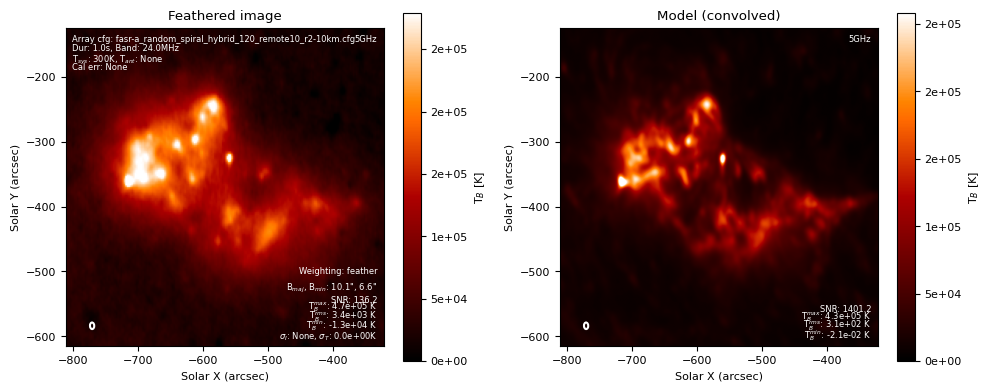

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_feather_uvthr2.0k_vs_solar_disk_model_20201126.5GHz.masked_feather_cropx17-37_y25-45.jpg
Applying a mask of 1.2 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image.image: 3.024e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image.image (excluding solar disk): 1.903e+03 K
SNR of the image: 158.9
Peak of solar_disk_model_20201126.5GHz.masked.im: 3.391e+05 K
rms of solar_disk_model_20201126.5GHz.masked.im (excluding solar disk): 3.068e+02 K
Plotting image with vmin=0.000e+00 K, vmax=1.814e+05 K
Plotting convolved image with vmin=0.000e+00 K, vmax=2.035e+05 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 21:15:36; runtime: 4

/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


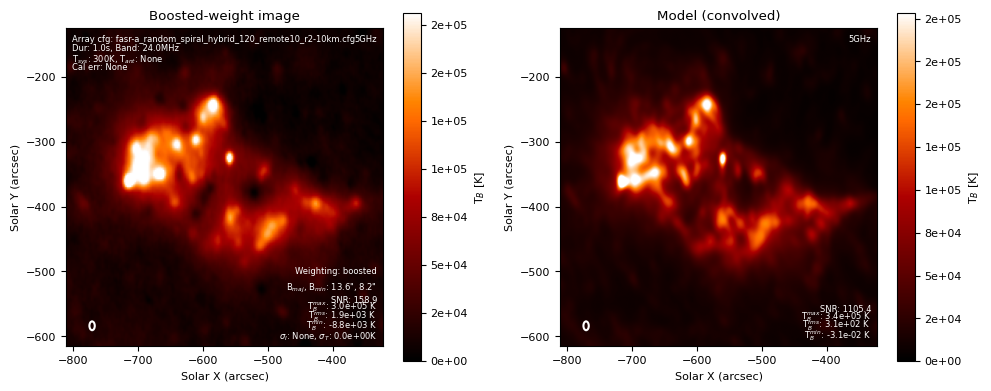

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_wboost_uv020k_p2.0_image_vs_solar_disk_model_20201126.5GHz.masked_boost_uv020k_p2.0_max10.0_cropx17-37_y25-45.jpg
Applying a mask of 1.2 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale.image: 2.936e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale.image (excluding solar disk): 1.708e+03 K
SNR of the image: 171.9
Peak of solar_disk_model_20201126.5GHz.masked.im: 3.226e+05 K
rms of solar_disk_model_20201126.5GHz.masked.im (excluding solar disk): 3.067e+02 K
Plotting image with vmin=0.000e+00 K, vmax=1.761e+05 K
Plotting convolved image with vmin=0.000e+00 K, vmax=1.935e+05 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 21:15:36; runtime: 0.14 seconds


/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


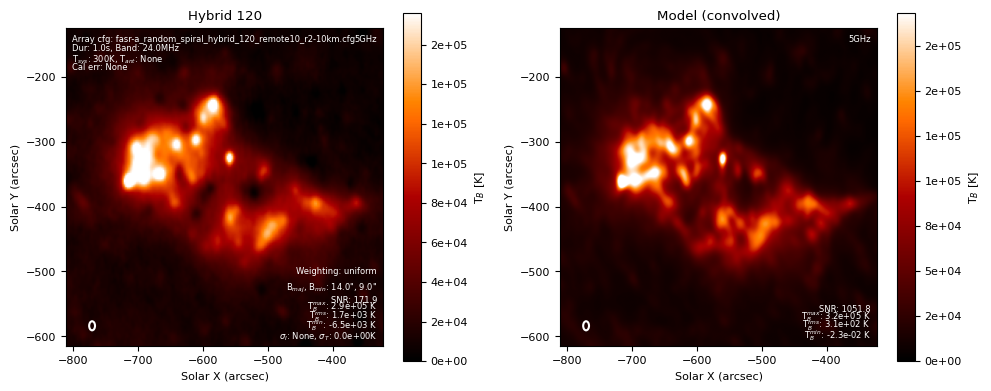

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale_vs_solar_disk_model_20201126.5GHz.masked_uniform_hybrid_cropx17-37_y25-45.jpg
Applying a mask of 1.2 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale.image: 3.049e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale.image (excluding solar disk): 1.839e+03 K
SNR of the image: 165.8
Peak of solar_disk_model_20201126.5GHz.masked.im: 3.636e+05 K
rms of solar_disk_model_20201126.5GHz.masked.im (excluding solar disk): 3.457e+02 K
Plotting image with vmin=0.000e+00 K, vmax=1.830e+05 K
Plotting convolved image with vmin=0.000e+00 K, vmax=2.182e+05 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 21:15:37; runtime: 0.14 seconds


/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


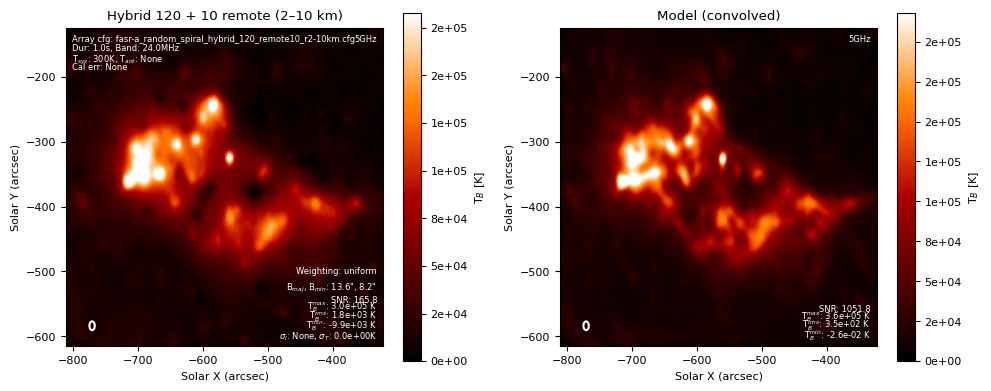

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uniform_multiscale_vs_solar_disk_model_20201126.5GHz.masked_uniform_remote_cropx17-37_y25-45.jpg
Applying a mask of 1.2 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvlt2.0k_2.4arcsec_natural.image: 1.290e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvlt2.0k_2.4arcsec_natural.image (excluding solar disk): 3.310e+02 K
SNR of the image: 389.8
Peak of solar_disk_model_20201126.5GHz.masked.im: 1.276e+05 K
rms of solar_disk_model_20201126.5GHz.masked.im (excluding solar disk): 3.306e+02 K
Plotting image with vmin=0.000e+00 K, vmax=7.741e+04 K
Plotting convolved image with vmin=0.000e+00 K, vmax=7.658e+04 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 21:15:41

/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


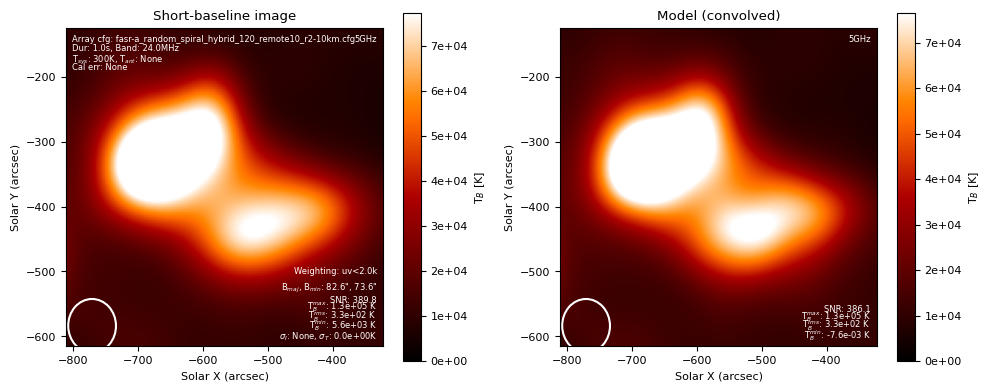

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvlt2.0k_2.4arcsec_natural_vs_solar_disk_model_20201126.5GHz.masked_short_uvlt2.0k_cropx17-37_y25-45.jpg
Applying a mask of 1.2 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvgt2.0k_2.4arcsec_uniform.image: 3.027e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvgt2.0k_2.4arcsec_uniform.image (excluding solar disk): 3.529e+03 K
SNR of the image: 85.8
Peak of solar_disk_model_20201126.5GHz.masked.im: 4.305e+05 K
rms of solar_disk_model_20201126.5GHz.masked.im (excluding solar disk): 3.072e+02 K
Plotting image with vmin=0.000e+00 K, vmax=1.816e+05 K
Plotting convolved image with vmin=0.000e+00 K, vmax=2.583e+05 K


/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2740: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rms_circle2 = Circle((0.0, 0.0), rms_radius_arcsec,
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2786: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  title2='Second Image',


'plot_two_casa_images_with_convolution' completed at 2026-02-11 21:15:43; runtime: 2.16 seconds


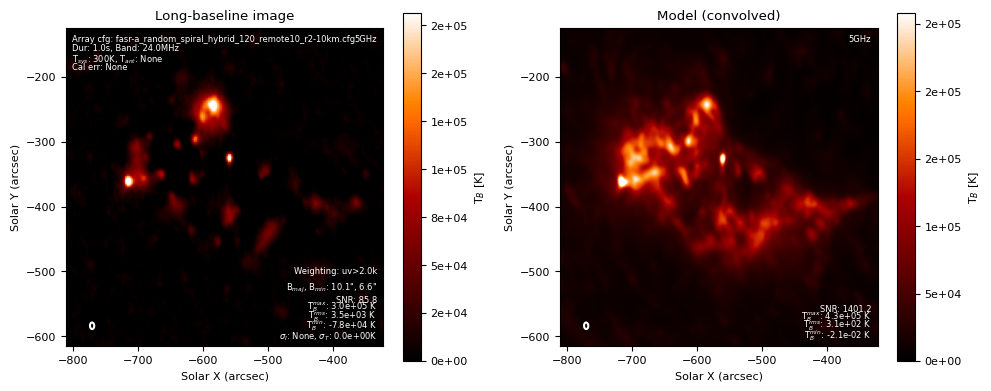

Saved figure: FASR-A/figs/fig-fasr_fasr-a_random_spiral_hybrid_120_remote10_r2-10km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_uvgt2.0k_2.4arcsec_uniform_vs_solar_disk_model_20201126.5GHz.masked_long_uvgt2.0k_cropx17-37_y25-45.jpg


In [26]:
from importlib import reload
reload(fss)
import os
import matplotlib.pyplot as plt

freqstr = '5GHz'

def _resolve_casa_image_path(path_hint):
    if path_hint is None:
        return None
    candidates = [
        path_hint,
        path_hint + '.image',
        path_hint[:-6] if path_hint.endswith('.image') else None,
    ]
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate
    return candidates[0]

feather_base = globals().get('feather_im', f'{msname_remote}_feather_uvthr{uvthr_klambda}k')
boost_base = globals().get('boost_im', msfile_boost.replace('.ms', '') + '_image' if 'msfile_boost' in globals() else None)
short_base = globals().get('short_im', None)
long_base = globals().get('long_im', None)

uniform_hybrid_base = f"{fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, base_cfg, tsys)}_uniform_multiscale"
uniform_remote_base = f"{fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, remote_cfg, tsys)}_uniform_multiscale"

model_fits = globals().get('solar_model', f'{model_dir}/solar_disk_model_20201126.{freqstr}.fits')
model_base = os.path.join(project, 'msfiles', target, os.path.basename(model_fits.replace('.fits', '.im')))

feather_path = _resolve_casa_image_path(feather_base)

boost_path = _resolve_casa_image_path(boost_base)
short_path = _resolve_casa_image_path(short_base)
long_path = _resolve_casa_image_path(long_base)
model_path = _resolve_casa_image_path(model_base)
uniform_hybrid_path = _resolve_casa_image_path(uniform_hybrid_base)
uniform_remote_path = _resolve_casa_image_path(uniform_remote_base)

missing = [
    p for p in [feather_path, boost_path, short_path, long_path, model_path, uniform_hybrid_path, uniform_remote_path]
    if (p is None or not os.path.exists(p))
]
if missing:
    raise FileNotFoundError('Missing CASA image(s): ' + ', '.join([str(x) for x in missing]))

image_meta_common = {
    'freq': freqstr,
    'array_config': remote_cfg,
    'tsys': f'{tsys:.0f}K' if 'tsys' in globals() else None,
    'tant': None,
    'sigma_jy': None,
    'cal_error': None,
    'duration': f'{duration}s' if 'duration' in globals() else None,
    'bandwidth': f'{channel_width_mhz}MHz' if 'channel_width_mhz' in globals() else None,
}

print('Using fss.plot_two_casa_images_with_convolution:')
print('  Feather:', feather_path)
print('  Boost  :', boost_path)
print('  Short  :', short_path)
print('  Long   :', long_path)
print('  Model  :', model_path)
print("  Uniform Hybrid 120:", uniform_hybrid_path)
print(f"  Uniform {remote_label}:", uniform_remote_path)

crop_fraction = (0.0, 1.0)  # use full image
vmax=50
crop_fraction = ((0.17, 0.37), (0.25, 0.45)) # zoom in on the disk (example values, adjust as needed)
vmax=60

def _base_tag(path):
    return os.path.basename(path).replace('.image', '').replace('.im', '')

def _crop_tag(crop):
    if isinstance(crop[0], float):
        return f"crop{int(crop[0]*100):02d}-{int(crop[1]*100):02d}"
    if isinstance(crop[0], (tuple, list)):
        return (
            f"cropx{int(crop[0][0]*100):02d}-{int(crop[0][1]*100):02d}"
            f"_y{int(crop[1][0]*100):02d}-{int(crop[1][1]*100):02d}"
        )
    return 'cropfull'

model_tag = _base_tag(model_path)
crop_tag = _crop_tag(crop_fraction)
boost_tag = f"boost_uv0{uv0_klambda}k_p{power}_max{max_boost}"
print('  Crop  :', crop_fraction, '->', crop_tag)


fig1, axs1 = fss.plot_two_casa_images_with_convolution(
    feather_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': ['Feathered image', 'Model (convolved)'], 'weighting': 'feather'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.feather',
    overwrite_conv=True,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(feather_path)}_vs_{model_tag}_feather_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig1.savefig(figname, dpi=200)
    print('Saved figure:', figname)

fig2, axs2 = fss.plot_two_casa_images_with_convolution(
    boost_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': ['Boosted-weight image', 'Model (convolved)'], 'weighting': 'boosted'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.boost',
    overwrite_conv=True,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(boost_path)}_vs_{model_tag}_{boost_tag}_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig2.savefig(figname, dpi=200)
    print('Saved figure:', figname)

fig3, axs3 = fss.plot_two_casa_images_with_convolution(
    uniform_hybrid_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': ['Hybrid 120', 'Model (convolved)'], 'weighting': 'uniform'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.uniform_compare',
    overwrite_conv=False,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(uniform_hybrid_path)}_vs_{model_tag}_uniform_hybrid_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig3.savefig(figname, dpi=200)
    print('Saved figure:', figname)

fig4, axs4 = fss.plot_two_casa_images_with_convolution(
    uniform_remote_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': [remote_label, 'Model (convolved)'], 'weighting': 'uniform'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.uniform_compare',
    overwrite_conv=False,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(uniform_remote_path)}_vs_{model_tag}_uniform_remote_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig4.savefig(figname, dpi=200)
    print('Saved figure:', figname)

fig5, axs5 = fss.plot_two_casa_images_with_convolution(
    short_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': ['Short-baseline image', 'Model (convolved)'], 'weighting': f'uv<{uvthr_klambda}k'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.short',
    overwrite_conv=True,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(short_path)}_vs_{model_tag}_short_uvlt{uvthr_klambda}k_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig5.savefig(figname, dpi=200)
    print('Saved figure:', figname)

fig6, axs6 = fss.plot_two_casa_images_with_convolution(
    long_path,
    model_path,
    crop_fraction=crop_fraction,
    rms_mask_radius=1.2,
    reftime=reftime,
    figsize=(15, 4),
    image_meta={**image_meta_common, 'title': ['Long-baseline image', 'Model (convolved)'], 'weighting': f'uv>{uvthr_klambda}k'},
    compare_two=False,
    contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4, 0.8],
    cmap='hinodexrt',
    vmax=vmax,
    vmin=0.0,
    conv_tag='.long',
    overwrite_conv=True,
)
plt.show()
figname = os.path.join(figdir, f"fig-{_base_tag(long_path)}_vs_{model_tag}_long_uvgt{uvthr_klambda}k_{crop_tag}.jpg")
if os.path.exists(figname) and overwrite_plot:
    os.system('rm -rf ' + figname)
if not os.path.exists(figname):
    fig6.savefig(figname, dpi=200)
    print('Saved figure:', figname)


In [22]:
ls "FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r3-6km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_feather_uvthr60k.image"


ls: FASR-A/msfiles/Quiet_Sun/fasr_fasr-a_random_spiral_hybrid_120_remote10_r3-6km_Quiet_Sun_5GHz_20201126T20UT_dur1s_int1s_noise300K_feather_uvthr60k.image: No such file or directory


In [17]:
from astropy.io import fits
solar_model_5ghz = f'{model_dir}/solar_disk_model_20201126.5GHz.fits'
hdul = fits.open(solar_model_5ghz)
header = hdul[0].header
header['CRVAL3'] = 5.01827669e9
hdul.writeto(solar_model_5ghz, overwrite=True)
hdul.close()


## Simulate visibility and do imaging

Total flux within primary beam used to calcuate the antenna temperature: 21.6 sfu
Tant: 83K
21.648125
Calculate antenna temperature from total flux 21.648125 sfu incident on the dish
Total noise temperature (K): 3.831e+02 K
Estimated SEFD: 1.072e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 1.295e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 2.077e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 1.548e+02 Jy for 7140 baselines
Start deconvolution
Generated phase calibration table: FASR-A/caltbs/caltb_FASR_corrupt_0deg.ph
Generated amplitude calibration table: caltb_FASR_corrupt_0pct.amp


2026-02-11 14:07:49	WARN	clearcal::calibrater::setvi(bool,bool)	Forcing use of OLD VisibilityIterator.
2026-02-11 14:07:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-11 14:07:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-11 14:07:49	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 


deconvolution completed in 0.37 minutes
Start plotting
Applying a mask of 1.4 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_1GHz_20201126T20UT_dur1s_int1s_noise300K_phaerr0deg_amperr0pct_multiscale.image: 1.284e+06 K
rms of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_1GHz_20201126T20UT_dur1s_int1s_noise300K_phaerr0deg_amperr0pct_multiscale.image (excluding solar disk): 1.880e+03 K
SNR of the image: 683.0
Peak of solar_disk_model_20201126.1GHz.masked.im: 1.280e+06 K
rms of solar_disk_model_20201126.1GHz.masked.im (excluding solar disk): 2.083e+02 K
Plotting image with vmin=-1.880e+04 K, vmax=6.421e+05 K
Plotting convolved image with vmin=-1.880e+04 K, vmax=6.421e+05 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 09:08:14; runtime: 3.36 seconds


/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2718: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ctick_labels)
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ctick_labels)


Total flux within primary beam used to calcuate the antenna temperature: 29.4 sfu
Tant: 113K
29.432328125
Calculate antenna temperature from total flux 29.432328125 sfu incident on the dish
Total noise temperature (K): 4.130e+02 K
Estimated SEFD: 1.156e+06 Jy
Estimated natural weighting point source sensitivity sigma_na: 1.396e+00 Jy/beam
Estimated uniform weighting point source sensitivity sigma_un: 1.847e+00 Jy/beam
Estimated noise per baseline per channel per polarization per integration: 1.669e+02 Jy for 7140 baselines
Start generating ms
Total flux within primary beam used to calcuate the antenna temperature: 29.4 sfu
Extracted from FITS header:
Frequency = 2GHz
Source RA = 4.238093 rad, DEC = -0.368072 rad
I am using hour angle for time specification.
Updated FASR-A/msfiles/Quiet_Sun/solar_disk_model_20201126.2GHz.masked.fits: CRVAL3 and RESTFRQ set to 2000000000.0 Hz
29.432328125
Calculate antenna temperature from total flux 29.432328125 sfu incident on the dish
Total noise temp

2026-02-11 14:08:16	WARN	clearcal::calibrater::setvi(bool,bool)	Forcing use of OLD VisibilityIterator.
2026-02-11 14:08:16	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Did not get the position of FASR from data repository
2026-02-11 14:08:16	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Please contact CASA to add it to the repository.
2026-02-11 14:08:16	WARN	SynthesisParamsImage::buildCoordinateSystem (file /Users/casaci/bamboohome/xml-data/build-dir/CASA-CRBC644PLUS0-BPOSX14ARMPY310/casa6/casatools/src/code/synthesis/ImagerObjects/SynthesisUtilMethods.cc, line 2940)	Using first antenna position as refence 


deconvolution completed in 0.37 minutes
Start plotting
Applying a mask of 1.3 solar radii to calcuate rms outside of it.
Peak of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_2GHz_20201126T20UT_dur1s_int1s_noise300K_phaerr0deg_amperr0pct_multiscale.image: 5.870e+05 K
rms of fasr_fasr-a_random_spiral_hybrid_120_Quiet_Sun_2GHz_20201126T20UT_dur1s_int1s_noise300K_phaerr0deg_amperr0pct_multiscale.image (excluding solar disk): 2.314e+03 K
SNR of the image: 253.7
Peak of solar_disk_model_20201126.2GHz.masked.im: 5.487e+05 K
rms of solar_disk_model_20201126.2GHz.masked.im (excluding solar disk): 1.001e+02 K
Plotting image with vmin=-2.314e+04 K, vmax=2.935e+05 K
Plotting convolved image with vmin=-2.314e+04 K, vmax=2.935e+05 K
'plot_two_casa_images_with_convolution' completed at 2026-02-11 09:08:41; runtime: 3.75 seconds


/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2718: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ctick_labels)
/Users/fisher/Library/Mobile Documents/com~apple~CloudDocs/work/research_project/ipynb_scripts_local/fasr-array-config-simul/fasr_solar_simul.py:2763: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ctick_labels)


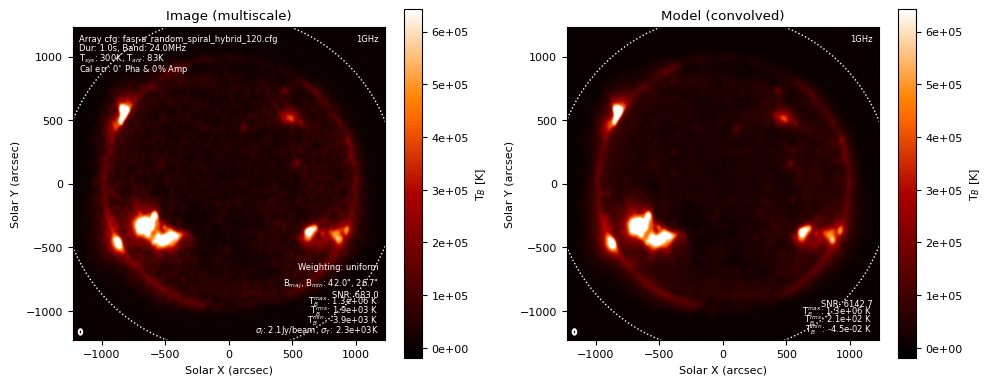

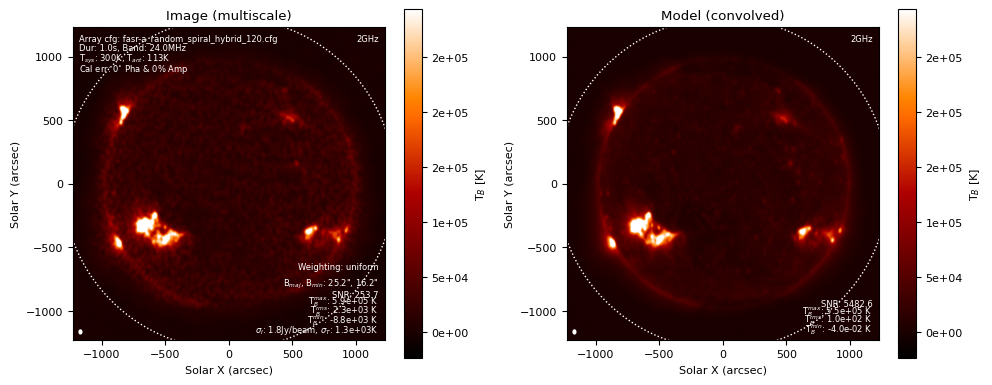

In [8]:
%matplotlib inline
reload(fss)

import time

reftime_casa = Time(reftime).strftime('%Y/%m/%d/%H:%M:%S')

figdir = os.path.join(project, figsubfolder)
if not os.path.exists(figdir):
    os.makedirs(figdir)
    
caltbdir = os.path.join(project, 'caltbs')
if not os.path.exists(caltbdir):
    os.makedirs(caltbdir)

for config_file in config_files:
    cfg_suffix = os.path.basename(config_file.rstrip(".cfg"))
    for freqstr, imsize, cell, scale in zip(freq_list, imsizes, cells, scales):
        solar_model = f'{model_dir}/solar_disk_model_20201126.{freqstr}.masked.fits'
        for tsys in tsys_all:
            # Calculate theoretical sensitivity with natural weighting
            antenna_params = np.genfromtxt(config_file, comments='#')
            dish_diameter = antenna_params[0, 3]
            uv_cell = 1. / (imsize * float(cell.rstrip('arcsec')) / 206265.)
            total_flux = fss.calc_total_flux_on_dish(solar_model, dish_diameter=dish_diameter, freqghz=freqstr)
            tant = fss.total_flux_to_tant(total_flux, eta_a=0.6, dish_diameter=dish_diameter)
            print(f'Tant: {tant:.0f}K')
            noisejy, sigma_na, sigma_un = fss.calc_noise(tsys, config_file, dish_diameter=dish_diameter, 
                                                         total_flux=total_flux, duration=duration,
                                                         integration_time=integration_time, 
                                                         channel_width_mhz=channel_width_mhz, 
                                                         freqghz=freqstr, uv_cell=uv_cell)
            sigma_jy = sigma_un / np.sqrt((duration / integration_time))
                
            for phaerr, amperr in cal_errors:
                phaerr_deg = np.rad2deg(phaerr * 2 * np.pi)
                gaintable = [f'caltb_FASR_corrupt_{phaerr_deg:.0f}deg.ph',
                             f'caltb_FASR_corrupt_{np.int_(amperr * 100)}pct.amp']
                msname = fss.make_msname(project, target, freqstr, Time(reftime).datetime, duration, integration_time, config_file, tsys)
                imname = fss.make_imname(msname, deconvolver, phaerr, amperr)
                if niter == 0:
                    imname = imname.replace(deconvolver, 'dirty')
                msfile = f'{msname}.ms'
                if os.path.exists(msfile):
                    if overwrite_ms:
                        os.system('rm -rf ' + msfile)
                    else:
                        pass
                
                if not os.path.exists(msfile):
                    print('Start generating ms')
                    msfile = fss.generate_ms(config_file, solar_model, reftime_casa, freqstr, integration_time=integration_time,
                                    duration=duration, channel_width_mhz=channel_width_mhz, 
                                    msname=msfile, tsys=tsys, usehourangle=True)

                if os.path.exists(f'{imname}.image'):
                    if overwrite_im:
                        junk = ['.image', '.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']
                        for j in junk:
                            os.system(f'rm -rf {imname}{j}')

                if not os.path.exists(f'{imname}.image'):
                    tstart = time.time()
                    print('Start deconvolution')
                    if not os.path.exists(gaintable[0]):
                        gaintable = fss.generate_caltb(msfile, caltype=['ph', 'amp'], 
                                                       calerr=[phaerr, amperr], caltbdir=caltbdir)
                    clearcal(vis=msfile)
                    applycal(vis=msfile, gaintable=gaintable, applymode='calonly', calwt=False)
                    if deconvolver == 'hogbom':
                        tclean(vis=msfile, imagename=imname,
                               datacolumn='corrected',
                               field='', spw='', specmode='mfs', 
                               deconvolver=deconvolver, pblimit=0.01,
                               imsize=imsize, cell=cell,
                               weighting=weighting,
                               niter=niter,
                               interactive=False)
                    elif deconvolver == 'multiscale':
                        tclean(vis=msfile, imagename=imname,
                               datacolumn='corrected',
                               field='', spw='', specmode='mfs', 
                               deconvolver=deconvolver, scales=scale, 
                               gain=0.2, cycleniter=200, minpsffraction=0.1, pblimit=0.01,
                               imsize=imsize, cell=cell,
                               weighting=weighting,
                               niter=niter,
                               interactive=False)                        
                    junk = ['.model', '.mask', '.pb', '.psf', '.residual', '.sumwt']
                    for j in junk:
                        os.system(f'rm -rf {imname}{j}')
                    tend = time.time()
                    print(f'deconvolution completed in {(tend - tstart)/60.:.2f} minutes')
                    

                figname = os.path.join(figdir, f'fig-{os.path.basename(imname)}.jpg')
                #figname = os.path.join(figdir, f'fig-{os.path.basename(imname)}.ar.jpg')
                if os.path.exists(figname):
                    if overwrite_plot:
                        os.system(f'rm -rf {figname}')

                if not os.path.exists(figname):
                    reload(fss)
                    ## cleaned image
                    image1 = imname + '.image'
                    ## model image
                    image2 = os.path.join(project+'/msfiles/Quiet_Sun/', os.path.basename(solar_model.replace('.fits', '.im')))
                    hdul = fits.open(solar_model)
                    header = hdul[0].header
                    radius_cutoff_rsun = header['RADCUT'] / solar_radius_asec
                    hdul.close()
                    ## meta information of the images
                    image_meta = {'title': [f'Image ({deconvolver})', 'Model (convolved)'],
                                  'freq': freqstr.lstrip("0"),
                                  'array_config': config_file,
                                  'tsys': f'{tsys:.0f}K',
                                  'tant': f'{tant:.0f}K',
                                  'sigma_jy': f'{sigma_jy:.1f}Jy/beam',
                                  'cal_error': f'{phaerr_deg:.0f}'+r'$^{\circ}$ Pha' + f' & {np.int_(amperr * 100)}% Amp',
                                  'duration': f'{duration}s',
                                  'bandwidth': f'{channel_width_mhz}MHz',
                                  'weighting': weighting,
                                  }
                    print('Start plotting')
                    fig, axs = fss.plot_two_casa_images_with_convolution(image1, image2,
                                                                         crop_fraction=(0.0, 1.0),
                                                                         #crop_fraction=((0.17, 0.37), (0.25, 0.45)),
                                                                         rms_mask_radius=radius_cutoff_rsun,
                                                                         reftime=reftime,
                                                                         figsize=(15, 4),
                                                                         image_meta=image_meta,
                                                                         cmap='hinodexrt',
                                                                         vmax=50,
                                                                         compare_two=False,
                                                                         contour_levels=[0.025, 0.05, 0.1, 0.2, 0.4,
                                                                                         0.8],
                                                                         conv_tag=f'.{cfg_suffix}',
                                                                         overwrite_conv=False)

                    fig.savefig(figname, dpi=300)